# Notebook 03 - Preparation des donnees

**Objectif du notebook**

Ce notebook correspond a la phase de preparation des donnees. L'objectif est de
transformer le dataset final en donnees exploitables pour l'apprentissage supervise,
tout en evitant le data leakage.

Dans cette phase, nous verifions la qualite des donnees, analysons les valeurs
manquantes, creons des variables derivees, realisons le split train/validation/test et
préparons le pipeline de preprocessing.

In [1]:
import sys
from pathlib import Path
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.features import (
    CATEGORICAL_FEATURES,
    MODEL_FEATURES,
    NUMERIC_FEATURES,
    add_engineered_features,
    prepare_model_input,
)


## Chargement du dataset et analyse des valeurs manquantes

Cette cellule charge le dataset final `data/dataset.csv` et vérifie sa structure générale : dimensions, doublons exacts et doublons sur le code produit.

Elle affiche ensuite le nombre et le pourcentage de valeurs manquantes pour chaque variable. Les valeurs manquantes ne sont pas remplacées directement dans ce dataset, car l’imputation sera faite plus tard dans le pipeline de preprocessing ajusté uniquement sur le train set.

Cette décision permet d’éviter le data leakage tout en conservant les lignes exploitables pour la modélisation.


In [2]:
df = pd.read_csv(ROOT / 'data' / 'dataset.csv')
print('Dimensions:', df.shape)
print('Doublons exacts:', df.duplicated().sum())
print('Codes dupliques:', df['code'].duplicated().sum())

missing = pd.DataFrame({
    'missing': df.isna().sum(),
    'missing_pct': df.isna().mean().mul(100).round(2),
})
missing['action'] = np.where(
    missing['missing'].gt(0),
    'Imputation dans le pipeline ajuste sur train',
    'Aucune action',
)
missing['justification'] = np.where(
    missing['missing'].gt(0),
    'Eviter le data leakage et conserver les lignes exploitables',
    'Variable complete',
)
display(missing)


Dimensions: (15079, 18)
Doublons exacts: 0
Codes dupliques: 0


,missing,missing_pct,action,justification
code,0,0.00,Aucune action,Variable complete
product_name,273,1.81,Imputation dans le pipeline ajuste sur train,Eviter le data leakage et conserver les lignes...
brands,404,2.68,Imputation dans le pipeline ajuste sur train,Eviter le data leakage et conserver les lignes...
main_category,0,0.00,Aucune action,Variable complete
country,0,0.00,Aucune action,Variable complete
sugars_100g,33,0.22,Imputation dans le pipeline ajuste sur train,Eviter le data leakage et conserver les lignes...
fat_100g,0,0.00,Aucune action,Variable complete
saturated_fat_100g,98,0.65,Imputation dans le pipeline ajuste sur train,Eviter le data leakage et conserver les lignes...
salt_100g,27,0.18,Imputation dans le pipeline ajuste sur train,Eviter le data leakage et conserver les lignes...
fiber_100g,3963,26.28,Imputation dans le pipeline ajuste sur train,Eviter le data leakage et conserver les lignes...


## Verification des incoherences metier

Cette cellule verifie que les variables nutritionnelles respectent des regles logiques.
Par exemple, les valeurs négatives sont impossibles, les nutriments exprimés en
grammes pour 100 g ne doivent pas dépasser 100, et les graisses saturées ne
doivent pas être supérieures aux graisses totales.

Ces verifications sont importantes car des valeurs incoherentes peuvent perturber
l'apprentissage du modèle.


In [3]:
nutrition = ['sugars_100g','fat_100g','saturated_fat_100g','salt_100g','fiber_100g','proteins_100g']
checks = {
    'valeurs_negatives': int((df[nutrition + ['energy_kcal_100g','additives_count']] < 0).sum().sum()),
    'valeurs_superieures_a_100g': int((df[nutrition] > 100).sum().sum()),
    'energie_superieure_a_1000': int((df['energy_kcal_100g'] > 1000).sum()),
    'graisses_saturees_superieures_aux_graisses': int((df['saturated_fat_100g'] > df['fat_100g']).sum()),
}
display(pd.Series(checks, name='nombre'))
assert sum(checks.values()) == 0


valeurs_negatives                             0
valeurs_superieures_a_100g                    0
energie_superieure_a_1000                     0
graisses_saturees_superieures_aux_graisses    0
Name: nombre, dtype: int64

## Analyse des outliers nutritionnels

Cette cellule analyse les valeurs extrêmes des variables nutritionnelles à l’aide de la méthode IQR.

Pour chaque variable, nous affichons un boxplot et nous comptons le nombre d’outliers détectés. Ces valeurs extrêmes ne sont pas supprimées automatiquement, car dans notre contexte elles peuvent représenter un vrai signal métier.

Par exemple, un produit très sucré, très gras, très salé ou très énergétique peut justement être un produit à risque nutritionnel. Nous décidons donc de conserver ces outliers lorsqu’ils restent dans des limites cohérentes et valides.

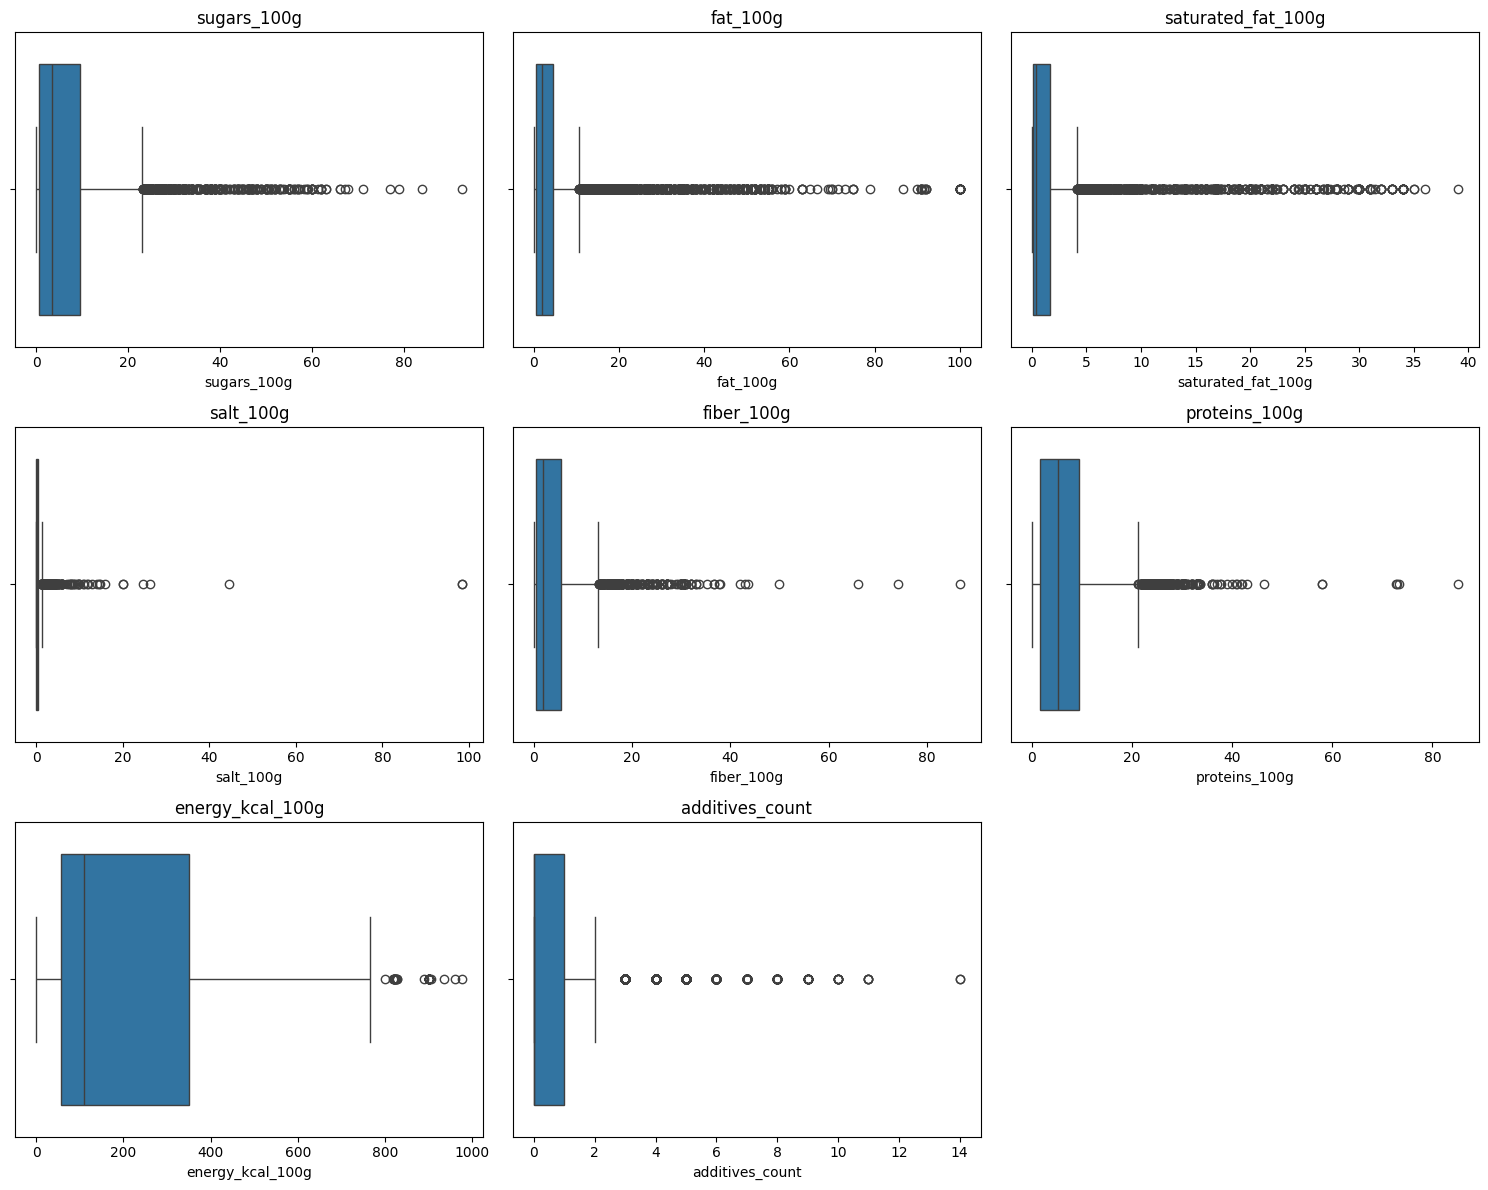

,variable,outliers_iqr,decision
0,sugars_100g,635,Conserver: valeurs valides et porteuses de signal
1,fat_100g,2015,Conserver: valeurs valides et porteuses de signal
2,saturated_fat_100g,1483,Conserver: valeurs valides et porteuses de signal
3,salt_100g,783,Conserver: valeurs valides et porteuses de signal
4,fiber_100g,377,Conserver: valeurs valides et porteuses de signal
5,proteins_100g,924,Conserver: valeurs valides et porteuses de signal
6,energy_kcal_100g,36,Conserver: valeurs valides et porteuses de signal
7,additives_count,1145,Conserver: valeurs valides et porteuses de signal


In [4]:
rows = []
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, column in zip(axes.flat, nutrition + ['energy_kcal_100g','additives_count']):
    values = df[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    count = int(((values < q1 - 1.5*iqr) | (values > q3 + 1.5*iqr)).sum())
    rows.append({'variable': column, 'outliers_iqr': count, 'decision': 'Conserver: valeurs valides et porteuses de signal'})
    sns.boxplot(x=values, ax=ax)
    ax.set_title(column)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()
display(pd.DataFrame(rows))


## Feature engineering
Dans cette étape, nous créons des variables dérivées à partir des variables nutritionnelles existantes.

Les variables ajoutées sont :

**sugar_energy_ratio :** rapport entre sucres et énergie

**sat_fat_ratio :** part des graisses saturées dans les graisses totales

**salt_sugar_interaction :** interaction entre sel et sucres

**nutrition_risk_score :** score synthétique de risque nutritionnel.

Ces variables permettent d’ajouter une logique métier au modèle et de mieux représenter le risque nutritionnel.


In [5]:
df_features = add_engineered_features(df)
engineered = ['sugar_energy_ratio','sat_fat_ratio','salt_sugar_interaction','nutrition_risk_score']
display(df_features[engineered].describe().T)


,count,mean,std,min,25%,50%,75%,max
sugar_energy_ratio,15036.0,3252.255990,280155.185473,0.000,0.003323,0.03114,0.096776,3.400000e+07
sat_fat_ratio,14981.0,0.282770,0.255856,0.000,0.110526,0.20000,0.454545,1.000000e+00
salt_sugar_interaction,15019.0,2.999619,17.674393,0.000,0.002000,0.31000,1.390000,1.475212e+03
nutrition_risk_score,11065.0,10.166772,16.631076,-77.022,2.360000,7.10000,14.650000,9.862200e+02


## Split stratifié train / validation / test

Cette cellule prépare les données finales utilisées pour la modélisation.

La fonction `prepare_model_input(df)` sélectionne les variables utiles au modèle et ajoute les variables dérivées créées pendant le feature engineering. La cible `bad_nutrition` est ensuite séparée des variables explicatives.

Le dataset est divisé en trois parties :

- `train` : 60 % des données, utilisé pour entraîner les modèles ;
- `validation` : 20 % des données, utilisé pour choisir le seuil métier ;
- `test` : 20 % des données, utilisé uniquement pour l’évaluation finale.

Le split est stratifié avec `stratify=y`, ce qui permet de conserver la même proportion de produits à mauvaise nutrition dans chaque sous-ensemble. Cela est important car la classe `bad_nutrition = 1` est minoritaire.

Les trois fichiers générés sont sauvegardés dans `data/processed/` afin d’être réutilisés dans les notebooks de modélisation, tuning et évaluation.

In [6]:
X = prepare_model_input(df)
y = df['bad_nutrition'].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=42
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

processed_dir = ROOT / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)
splits = {
    'train': pd.concat([X_train, y_train.rename('bad_nutrition')], axis=1),
    'validation': pd.concat([X_validation, y_validation.rename('bad_nutrition')], axis=1),
    'test': pd.concat([X_test, y_test.rename('bad_nutrition')], axis=1),
}
for name, split in splits.items():
    split.to_csv(processed_dir / f'{name}.csv', index=False)

summary = pd.DataFrame({
    name: {'lignes': len(data), 'ratio_positif': data.bad_nutrition.mean()}
    for name, data in splits.items()
}).T
display(summary)


,lignes,ratio_positif
train,9047.0,0.174533
validation,3016.0,0.174735
test,3016.0,0.174403


## Construction et sauvegarde du pipeline de preprocessing

Cette cellule construit le pipeline de preprocessing utilisé avant l’entraînement des modèles.

Les variables numériques sont traitées avec une imputation par médiane, puis standardisées avec `StandardScaler`. Les variables catégorielles et binaires sont traitées avec une imputation par la modalité la plus fréquente, puis encodées avec `OneHotEncoder`.

Le `ColumnTransformer` permet d’appliquer le bon traitement à chaque groupe de variables : numériques, catégorielles et binaires.

Le préprocesseur est ajusté uniquement sur `X_train`, afin d’éviter le data leakage. Ensuite, il sera réutilisé dans les notebooks de modélisation, tuning, évaluation et déploiement.

Le pipeline est sauvegardé dans `models/preprocessor.joblib` pour garantir la reproductibilité du projet.


In [7]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, NUMERIC_FEATURES),
    ('categorical', categorical_pipeline, ['main_category', 'country']),
    ('binary', binary_pipeline, ['has_labels', 'image_saine']),
])
preprocessor.fit(X_train)

models_dir = ROOT / 'models'
models_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(preprocessor, models_dir / 'preprocessor.joblib')
print(preprocessor)
print('Pipeline ajuste uniquement sur train.csv puis serialise dans models/preprocessor.joblib.')


ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['sugars_100g', 'fat_100g',
                                  'saturated_fat_100g', 'salt_100g',
                                  'fiber_100g', 'proteins_100g',
                                  'energy_kcal_100g', 'additives_count',
                                  'sugar_energy_ratio', 'sat_fat_ratio',
                                  'salt_sugar_interaction',
                                  'nutrition_risk_score']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
      

## Préparation des stratégies de gestion du déséquilibre

Cette cellule prépare les différentes stratégies qui seront comparées pendant la modélisation.

Comme la classe `bad_nutrition = 1` est minoritaire, nous testons plusieurs approches :

* `baseline` : aucune modification des données, mais pondération des classes dans le modèle ;
* `SMOTE` : création d’exemples synthétiques pour la classe minoritaire ;
* `RandomUnderSampler` : réduction du nombre d’exemples de la classe majoritaire ;
* `SMOTETomek` : combinaison de SMOTE et d’un nettoyage des exemples ambigus.

Ces stratégies seront intégrées dans un `imblearn Pipeline`, afin que le rééchantillonnage soit appliqué uniquement pendant l’entraînement et jamais sur la validation ou le test.


In [8]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

strategies = {
    'baseline': None,
    'smote': SMOTE(random_state=42),
    'undersample': RandomUnderSampler(random_state=42),
    'smote_tomek': SMOTETomek(random_state=42),
}
display(pd.Series({name: type(value).__name__ if value else 'class_weight' for name, value in strategies.items()}))


baseline             class_weight
smote                       SMOTE
undersample    RandomUnderSampler
smote_tomek            SMOTETomek
dtype: str

## Synthese
À la fin, nous obtenons :

- Un dataset propre
- Des variables dérivées justifiées métier 
- Un split train/validation/test stratifié 
- Un pipeline de preprocessing réutilisable 
- Des stratégies de déséquilibre prêtes pour la modélisation
